In [1]:
import numpy as np
from zfish._io import import16chFlt
import matplotlib.pyplot as plt
from tqdm import tqdm
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import *

code_id = "5003 - Dao Fish Analysis"
loc = join(figpath, code_id)
mkdir(loc)
pass

        D:\Yao Shuyang\En Lab\Results\5003 - Dao Fish Analysis is already existed!


In [6]:
def get_p_only(path):
    res = import16chFlt(path)
    assert res['Paradigm'][0] == 59595, "Need Godarkgo paradigm data."
    
    base_name = os.path.basename(os.path.dirname(path))
    dir_name = os.path.dirname(os.path.dirname(path))
    save_dir = os.path.join(dir_name, 'analysis_results')
    mkdir(save_dir)

    state = np.zeros(len(res['behav_time']))
    state[res['behav_pos_y'] > 0.5] = 1

    mean_signals = (res['fltCh0'] + res['fltCh1']) / 2
    mean_signals = np.convolve(mean_signals, np.ones(100)/100, mode='same')

    engagement_score, p_value, engagement_shuf = calc_engagement_score(
        mean_signals, state,
        v_percent=95, n_shuffle=1000
    )
    return engagement_score, p_value

def plot_godarkgo(path) -> Axes:
    res = import16chFlt(path)
    assert res['Paradigm'][0] == 59595, "Need Godarkgo paradigm data."
    
    base_name = os.path.basename(os.path.dirname(path))
    dir_name = os.path.dirname(os.path.dirname(path))
    save_dir = os.path.join(dir_name, 'analysis_results')
    mkdir(save_dir)

    state = np.zeros(len(res['behav_time']))
    state[res['behav_pos_y'] > 0.5] = 1

    mean_signals = (res['fltCh0'] + res['fltCh1']) / 2
    mean_signals = np.convolve(mean_signals, np.ones(100)/100, mode='same')

    engagement_score, p_value, engagement_shuf = calc_engagement_score(
        mean_signals, state,
        v_percent=95, n_shuffle=1000
    )
    print(f'Engagement Score: {engagement_score}, p-value: {p_value}')
    
    max_time = res['behav_time'][-1]
    # Engagement score change over time
    n_iter = 0
    data = {
        "Time Steps": [],
        "Engagement Score": [],
        "Type": []
    }
    x = []
    y = []
    y_mean = []
    upper_bound = []
    lower_bound = []
    while n_iter * 50 + 25 < max_time:
        range_idx = np.where(
            (res['behav_time'] >= n_iter * 50) & (res['behav_time'] < n_iter * 50 + 50)
        )[0]
        engagement_score_time, _, engagement_score_time_shuf = calc_engagement_score(
            mean_signals[range_idx],
            state[range_idx],
            v_percent=99, n_shuffle=1000
        )
        upper_bound.append(np.percentile(engagement_score_time_shuf, 95))
        lower_bound.append(np.min(engagement_score_time_shuf, 0))
        x.append(n_iter * 50 + 25)
        y.append(engagement_score_time)
        y_mean.append(np.mean(engagement_score_time_shuf))
        data["Time Steps"].append(np.repeat(n_iter * 50 + 25, 1001))
        data["Engagement Score"].append(np.concatenate([[engagement_score_time], engagement_score_time_shuf]))
        data["Type"].append(np.concatenate([['Data'], np.repeat('Shuf', 1000)]))
        n_iter += 1
    
    for k in data.keys():
        data[k] = np.concatenate(data[k])
    data = LengthAlignedDict(data)

    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        
    ax.plot(res['behav_time'], res['fltCh0'], linewidth=0.5, color=ChannelColors[0])
    ax.plot(res['behav_time'], -res['fltCh1'], linewidth=0.5, color=ChannelColors[1])
    ax.plot(res['behav_time'], state*0.0003, linewidth=1, color='k')
    ax.set_title(f'engagement score: {engagement_score:.3f} (p={p_value:.3f})')

    ylim = 0.0008
    ax.set_ylim([-ylim, ylim])
    ax.set_yticks(np.linspace(-ylim, ylim, 5))
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement.png"))
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement.svg"))
    plt.close()
    
    # Shuffle test
    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    ax.hist(engagement_shuf, bins=40, range=(0, 1), color='gray', alpha=0.7)
    axt = Clear_Axes(ax.twinx(), close_spines=['top', 'left'], ifxticks=True, ifyticks=True)
    sns.ecdfplot(engagement_shuf, ax=axt, color='blue')
    axt.set_ylim(0, 1)
    axt.set_yticks(np.linspace(0, 1, 6))
    axt.spines['right'].set_color('blue')
    ax.axvline(engagement_score, color='red', linestyle='--', label='Observed Score')
    ax.set_xlim([0, 1])
    axt.set_xlim([0, 1])
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement_shuf_distribution.png"))
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement_shuf_distribution.svg"))
    plt.close()

    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    ax.fill_between(x, lower_bound, upper_bound, color='gray', alpha=0.3, edgecolor=None)
    ax.plot(x, y_mean, color='gray', marker='s', markersize=8, markeredgewidth=0, label='Shuffle')
    ax.plot(x, y, color='k', marker='o', markersize=8, markeredgewidth=0, label='Data')
    ax.legend(fontsize=8)
    ax.set_title(f'Engagement Score Over Time')
    ax.set_xlabel('Time Segment')
    ax.set_ylabel('Engagement Score')
    ax.set_ylim([0, 1])
    ax.set_yticks(np.linspace(0, 1, 6))
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement_over_time.png"))
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement_over_time.svg"))
    plt.close()

    return data

if exists(join(figdata, f"{code_id} [engagement score].pkl")) == False:
    EngageData = {
        "FishID": [],
        "Time Steps": [],
        "Engagement Score": [],
        "Type": [],
        "Session": [],
        "Is Paralyzed": []
    }

    for i in range(len(f_dao_opt)):
        if f_dao_opt['session'][i] in [1, 5]:
            print(f"Processing Fish ID: {f_dao_opt['ID'][i]}, Session: {f_dao_opt['session'][i]}") 
            data = plot_godarkgo(f_dao_opt['filename'][i])
            
            EngageData['FishID'].append(np.repeat(f_dao_opt['ID'][i], data.shape[0]))
            EngageData['Time Steps'].append(data["Time Steps"])
            EngageData['Engagement Score'].append(data["Engagement Score"])
            EngageData['Type'].append(data["Type"])
            EngageData['Session'].append(np.repeat(f_dao_opt['session'][i], data.shape[0]))
            EngageData['Is Paralyzed'].append(np.repeat(f_dao_opt['Group'][i], data.shape[0]))
            
    for k in EngageData.keys():
        EngageData[k] = np.concatenate(EngageData[k])
        
    EngageData = LengthAlignedDict(EngageData)
    with open(join(figdata, f"{code_id} [engagement score].pkl"), 'wb') as f:
        pickle.dump(EngageData, f)
        
    EngageD = pd.DataFrame(EngageData)
    EngageD.to_excel(join(figdata, f"{code_id} [engagement score].xlsx"), index=False)
    print(len(EngageData))
else:
    with open(join(figdata, f"{code_id} [engagement score].pkl"), 'rb') as f:
        EngageData: LengthAlignedDict = pickle.load(f)

if exists(join(figdata, f" {code_id} [engagement score P-value].pkl")) == False:
    EngagePvals = {
        "FishID": [],
        "Engagement Score": [],
        "Engagement P-value": [],
        "Session": [],
        "Is Paralyzed": []
    }
    
    for i in range(len(f_dao_opt)):
        if f_dao_opt['session'][i] in [1, 5]:
            print(f"Processing Fish ID: {f_dao_opt['ID'][i]}, Session: {f_dao_opt['session'][i]}") 
            engage_score, p_value = get_p_only(f_dao_opt['filename'][i])
            
            EngagePvals['FishID'].append(f_dao_opt['ID'][i])
            EngagePvals['Engagement Score'].append(engage_score)
            EngagePvals['Engagement P-value'].append(p_value)
            EngagePvals['Session'].append(f_dao_opt['session'][i])
            EngagePvals['Is Paralyzed'].append(f_dao_opt['Group'][i])
    
    for k in EngagePvals.keys():
        EngagePvals[k] = np.array(EngagePvals[k])
        
    EngagePvals = LengthAlignedDict(EngagePvals)
    with open(join(figdata, f"{code_id} [engagement score P-value].pkl"), 'wb') as f:
        pickle.dump(EngagePvals, f) 
        
    EngagePvalsD = pd.DataFrame(EngagePvals)
    EngagePvalsD.to_excel(join(figdata, f"{code_id} [engagement score P-value].xlsx"), index=False)
    print(len(EngagePvals))
else:
    with open(join(figdata, f"{code_id} [engagement score P-value].pkl"), 'rb') as f:
        EngagePvals: LengthAlignedDict = pickle.load(f)
        
EngagePvals['Engagement P-value'] = np.clip(EngagePvals['Engagement P-value'], 1e-4, 1) 
fig = plt.figure(figsize=(2, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.axhline(0.05, color='k', linestyle='--', lw=0.5)
sns.lineplot(
    x='Session',
    y='Engagement P-value',
    hue='FishID',
    data=EngagePvals,
    legend=False,
    marker='o',
    linewidth=0.5,
    markersize=8,
    markeredgewidth=0,
    ax=ax
)
ax.set_xlim(-1, 7)

ax.set_xticks([1, 5], ['Pre', 'Post'])
ax.set_title("GoDarkGo Task")
ax.semilogy()
plt.savefig(join(loc, "GoDarkGo Engagement P-values.png"), dpi=600)
plt.savefig(join(loc, "GoDarkGo Engagement P-values.svg"), dpi=600)
plt.show()

Processing Fish ID: 10071, Session: 1
        D:\EnData\Dao-CoChr\10071\analysis_results is already existed!


100%|██████████| 1000/1000 [00:19<00:00, 51.76it/s]


Processing Fish ID: 10071, Session: 5
        D:\EnData\Dao-CoChr\10071\analysis_results is already existed!


100%|██████████| 1000/1000 [00:12<00:00, 82.59it/s]


Processing Fish ID: 10075, Session: 1
        D:\EnData\Dao-CoChr\10075\analysis_results is already existed!


...

100%|██████████| 1000/1000 [00:40<00:00, 24.61it/s]


Processing Fish ID: 10114, Session: 5
        D:\EnData\Dao-CoChr\10114\analysis_results is already existed!


100%|██████████| 1000/1000 [00:33<00:00, 29.92it/s]


Processing Fish ID: 10116, Session: 1


ValueError: cannot reshape array of size 43849800 into shape (16)

# Opt Pretest

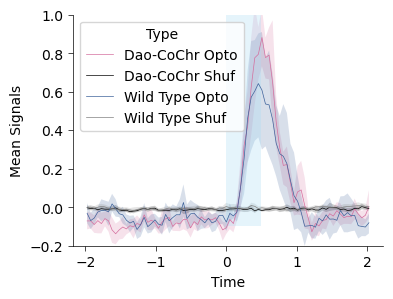

(0,) (0,) (0,) (0,)
TtestResult(statistic=nan, pvalue=nan, df=nan)
TtestResult(statistic=nan, pvalue=nan, df=nan)


C:\Users\Shuyang Yao\AppData\Local\Temp\ipykernel_29100\3851933938.py:210: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(ttest_rel(
C:\Users\Shuyang Yao\AppData\Local\Temp\ipykernel_29100\3851933938.py:214: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print(ttest_rel(


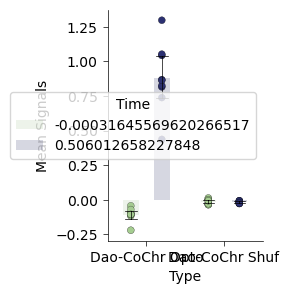

In [5]:
def segmentation(path, n_shuffle=1000):
    res1d = import16chFlt(path)
    state = np.zeros(len(res1d['behav_time']))
    state[res1d['behav_pos_y'] > 98] = 1
    opt_state = res1d['opto_states']

    res1d['fltCh0'] = (res1d['fltCh0'] - np.mean(res1d['fltCh0'])) / np.std(res1d['fltCh0'])
    res1d['fltCh1'] = (res1d['fltCh1'] - np.mean(res1d['fltCh1'])) / np.std(res1d['fltCh1'])
    res1d['behav_speed_y'][state == 0] = (res1d['behav_speed_y'][state == 0] - np.mean(res1d['behav_speed_y'][state == 0])) / np.std(res1d['behav_speed_y'][state == 0])

    if res1d['Paradigm'][0] in [20250921, 20250920, 20251113, 20251112]:
        print("hahah")
        state_transition = np.where(np.diff(state) != 0)[0]
        excluded_indices = []
        for i in state_transition:
            transition_time = res1d['behav_time'][i]
            excluded_indices.append(np.where((res1d['behav_time'] >= transition_time - 2) & (res1d['behav_time'] <= transition_time + 2))[0])
        excluded_indices.append(np.where(state == 1)[0])
        excluded_indices = np.unique(np.concatenate(excluded_indices))
    else:
        max_t = res1d['behav_time'][-1]
        excluded_indices = np.where(
            (res1d['behav_time'] <= 2) | (res1d['behav_time'] >= max_t - 2)
        )[0]

    opt_state[opt_state == -1] = 0
    realigned_data = event_based_realignment(
        res1d,
        state=opt_state,
        segmented_keys=['behav_speed_y', 'fltCh0', 'fltCh1'],
        excluded_idx=excluded_indices,
    )
    realigned_data['Type'] = np.repeat('Opto', realigned_data.shape[0])
    realigned_data_shuf = event_based_realignment(
        res1d,
        state=state,
        segmented_keys=['behav_speed_y', 'fltCh0', 'fltCh1'],
        excluded_idx=excluded_indices,
        is_shuffle=True,
        n_shuffle=n_shuffle
    )
    realigned_data_shuf['Type'] = np.repeat('Shuf', realigned_data_shuf.shape[0])
    data = realigned_data + realigned_data_shuf
    return data

def visualize_opt_pretest(path):
    data = segmentation(path)
    base_name = os.path.basename(os.path.dirname(path))
    dir_name = os.path.dirname(os.path.dirname(path))
    save_dir = os.path.join(dir_name, 'analysis_results')
    mkdir(save_dir)
    
    fig = plt.figure(figsize=(4, 2))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    data['mean_signals'] = (data['realigned_fltCh0'] + data['realigned_fltCh1']) / 2
    sns.lineplot(
        x='realigned_time',
        y='mean_signals',
        hue='Type',
        data=data,
        palette=['red', 'k'],
        linewidth=0.5,
        err_kws={'edgecolor': None},
        ax=ax,
        zorder=2
    )
    ylim = ax.get_ylim()
    ax.fill_betweenx([-0.3, 2], 0, 0.5, color='#a9dcf5', alpha=0.3, edgecolor=None)
    ax.set_ylim(-0.5, 2)
    ax.set_yticks(np.linspace(-0.5, 2, 6))
    plt.savefig(join(save_dir, f"Opt Pretest [Swim Signals].png"), dpi=600)
    plt.savefig(join(save_dir, f"Opt Pretest [Swim Signals].svg"), dpi=600)
    plt.close()

"""
for i in range(len(f_dao_opt)):
    if f_dao_opt['session'][i] == 2:
        print(f"Visualizing Opt Pretest for Fish ID: {f_dao_opt['ID'][i]}") 
        visualize_opt_pretest(f_dao_opt['filename'][i])
"""
if exists(join(figdata, f"{code_id} [Opt Pretest].pkl")) == False:
    OptPreTestData = {
        "FishID": [],
        "Time": [],
        "Mean Signals": [],
        "Type" : []
    }
    for i in range(100):
        if f_dao_opt['session'][i] == 2:
            print(f"Fish: {f_dao_opt['ID'][i]}")
            data = segmentation(f_dao_opt['filename'][i])
            data['mean_signals'] = (data['realigned_fltCh0'] + data['realigned_fltCh1']) / 2
            time_bins = np.unique(data['realigned_time'])
            mean_signals_opt = np.zeros(len(time_bins))
            mean_signals_shuf = np.zeros(len(time_bins))
            
            for j, t in enumerate(time_bins):
                mean_signals_opt[j] = np.mean(data['mean_signals'][(data['realigned_time'] == t) & (data['Type'] == 'Opto')])
                mean_signals_shuf[j] = np.mean(data['mean_signals'][(data['realigned_time'] == t) & (data['Type'] == 'Shuf')])
            
            OptPreTestData['FishID'].append(np.repeat(f_dao_opt['ID'][i], len(time_bins)*2))
            OptPreTestData['Time'].append(np.concatenate([time_bins, time_bins]))
            OptPreTestData['Mean Signals'].append(np.concatenate([mean_signals_opt, mean_signals_shuf]))
            type_name = f"{f_dao_opt['Genotype'][i]} Opto"
            type_name_shuf = f"{f_dao_opt['Genotype'][i]} Shuf"
            OptPreTestData['Type'].append(np.concatenate([np.repeat(type_name, len(time_bins)), np.repeat(type_name_shuf, len(time_bins))]))
    
    for k in OptPreTestData.keys():
        OptPreTestData[k] = np.concatenate(OptPreTestData[k])
        
    OptPreTestData = LengthAlignedDict(OptPreTestData)
    with open(join(figdata, f"{code_id} [Opt Pretest].pkl"), 'wb') as f:
        pickle.dump(OptPreTestData, f)
        
    OptPreTestD = pd.DataFrame(OptPreTestData)
    OptPreTestD.to_excel(join(figdata, f"{code_id} [Opt Pretest].xlsx"), index=False)
    print(len(OptPreTestData))
else:
    with open(join(figdata, f"{code_id} [Opt Pretest].pkl"), 'rb') as f:
        OptPreTestData: LengthAlignedDict = pickle.load(f)

# Data exclusion: Exclude fish with abnormal signals: 10092, 10093, 10100
# Include the second S2 session of 10089 and 10091 as they have conducted two sessions on the same day.
subdata = OptPreTestData.subdict(np.where(np.isin(OptPreTestData['FishID'], [10092, 10093, 10100]) == False)[0])

# Keep only the latest time bin before optogenetic stimulus and the earliest time bin after optogenetic stimulus

for fish in [10089, 10091]:
    dt = np.diff(subdata['Time'][subdata['FishID'] == fish])
    idx_transition = np.where(dt < 0)[0][1] + 1
    exclude_idx = np.where(subdata['FishID'] == fish)[0][:idx_transition]
    for k in subdata.keys():
        subdata[k] = np.delete(subdata[k], exclude_idx)

fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='Time',
    y='Mean Signals',
    hue='Type',
    data=subdata,
    palette=[ChannelColors[0], 'k', ChannelColors[1], 'gray'],
    linewidth=0.5,
    err_kws={'edgecolor': None},
    ax=ax
)
ax.fill_betweenx([-0.1, 1], 0, 0.5, color='#a9dcf5', alpha=0.3, edgecolor=None)
ax.set_ylim(-0.2, 1)
ax.set_yticks(np.linspace(-0.2, 1, 7))
plt.savefig(join(loc, "Opt Pretest [Swim Signals].png"), dpi=600)
plt.savefig(join(loc, "Opt Pretest [Swim Signals].svg"), dpi=600)
plt.show()
        
fig = plt.figure(figsize=(2, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
idx = np.where(
    ((subdata['Time'] > - 0.025) & (subdata['Time'] < 0)) | 
    ((subdata['Time'] > 0.5) & (subdata['Time'] < 0.525))
)[0]
subdata = subdata.subdict(idx)
sns.stripplot(
    x='Type',
    y='Mean Signals',
    hue='Time',
    data=subdata,
    palette='crest',
    size=5,
    linewidth=0.2,
    edgecolor='k',
    jitter=0,
    dodge=True,
    ax=ax,
    zorder=1,
    legend=False
)
sns.barplot(
    x='Type',
    y='Mean Signals',
    data=subdata,
    hue='Time',
    palette='crest',
    alpha=0.2,
    capsize=0.3, 
    gap=0.5,
    width=0.8,
    err_kws={'linewidth': 0.5, 'color':'k'},
    zorder=2
)
idx_opt_bef = np.where((subdata['Type'] == 'Opto') & (subdata['Time'] < 0))[0]
idx_opt_aft = np.where((subdata['Type'] == 'Opto') & (subdata['Time'] > 0.5))[0]
idx_shuf_bef = np.where((subdata['Type'] == 'Shuf') & (subdata['Time'] < 0))[0]
idx_shuf_aft = np.where((subdata['Type'] == 'Shuf') & (subdata['Time'] > 0.5))[0]
print(idx_opt_bef.shape, idx_opt_aft.shape, idx_shuf_bef.shape, idx_shuf_aft.shape)
for i in range(len(idx_opt_bef)):
    ax.plot(
        [0 - 0.2, 0 + 0.2],
        [subdata['Mean Signals'][idx_opt_bef[i]], subdata['Mean Signals'][idx_opt_aft[i]]],
        color='k',
        linewidth=0.5,
        zorder=0
    )
    ax.plot(
        [1 - 0.2, 1 + 0.2],
        [subdata['Mean Signals'][idx_shuf_bef[i]], subdata['Mean Signals'][idx_shuf_aft[i]]],
        color='k',
        linewidth=0.5,
        zorder=0
    )
ax.set_xlim(-0.5, 1.5)
print(ttest_rel(
    subdata['Mean Signals'][idx_opt_bef],
    subdata['Mean Signals'][idx_opt_aft]
))
print(ttest_rel(
    subdata['Mean Signals'][idx_shuf_bef],
    subdata['Mean Signals'][idx_shuf_aft]
))
plt.savefig(join(loc, "Opt Pretest [Swim Signals Paired].png"), dpi=600)
plt.savefig(join(loc, "Opt Pretest [Swim Signals Paired].svg"), dpi=600)
plt.show()

# Session 4 Speed_coupled 1D

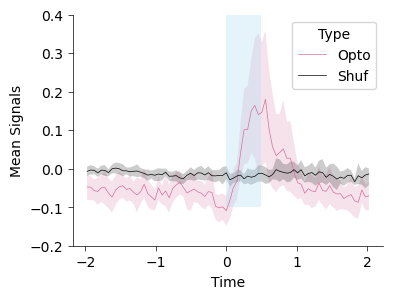

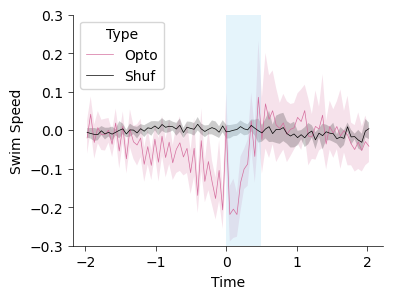

(16,) (16,) (16,) (16,)
TtestResult(statistic=-2.6625174185373974, pvalue=0.017741796137850707, df=15)
TtestResult(statistic=nan, pvalue=nan, df=nan)


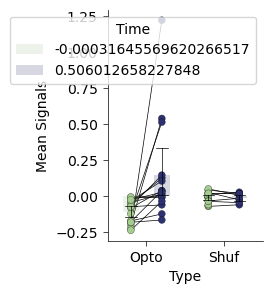

(16,) (16,) (16,) (16,)
TtestResult(statistic=0.4642306620527122, pvalue=0.6491486276082803, df=15)
TtestResult(statistic=nan, pvalue=nan, df=nan)


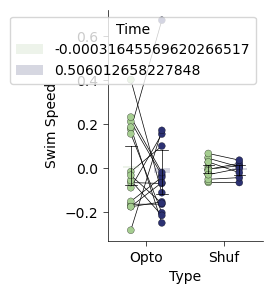

In [10]:
def visualize_speed_couple(path, data = None):
    if data is None:
        data = segmentation(path, n_shuffle=100)
    
    base_name = os.path.basename(os.path.dirname(path))
    dir_name = os.path.dirname(os.path.dirname(path))
    save_dir = os.path.join(dir_name, 'analysis_results')
    mkdir(save_dir)
    
    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    sns.lineplot(
        x='realigned_time',
        y='realigned_behav_speed_y',
        hue='Type',
        data=data,
        linewidth=0.5,
        err_kws={'edgecolor': None},
        ax=ax, 
        zorder=2
    )
    ylim = ax.get_ylim()
    ax.set_title(f"n = {np.unique(data['n_events']).shape[0]} stimulus", fontsize=8)
    ax.fill_betweenx([-0.5, 1], 0, 0.5, color=LEDColor, alpha=0.3, edgecolor=None, zorder=1)
    ax.set_yticks(np.linspace(-0.5, 1, 4))
    ax.set_ylim(-0.5, 1)
    plt.savefig(join(save_dir, f"Speed-Coupled 1D [Swim Speed].png"), dpi=600)
    plt.savefig(join(save_dir, f"Speed-Coupled 1D [Swim Speed].svg"), dpi=600)
    plt.close()
    
    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    data['mean_signals'] = (data['realigned_fltCh0'] + data['realigned_fltCh1']) / 2
    sns.lineplot(
        x='realigned_time',
        y='mean_signals',
        hue='Type',
        data=data,
        linewidth=0.5,
        err_kws={'edgecolor': None},
        ax=ax,
        zorder=2
    )
    ylim = ax.get_ylim()
    ax.set_title(f"n = {np.unique(data['n_events']).shape[0]} stimulus", fontsize=8)
    ax.fill_betweenx([-0.5, 1.5], 0, 0.5, color=LEDColor, alpha=0.3, edgecolor=None, zorder=1)
    ax.set_ylim(-0.5, 1.5)
    ax.set_yticks(np.linspace(-0.5, 1.5, 5))
    plt.savefig(join(save_dir, f"Speed-Coupled 1D [Mean Signals].png"), dpi=600)
    plt.savefig(join(save_dir, f"Speed-Coupled 1D [Mean Signals].svg"), dpi=600)
    plt.close()
    
if exists(join(figdata, f"{code_id} [Speed-Coupled 1D].pkl")) == False:
    SpeedCoupled1D = {
        "FishID": [],
        "Time": [],
        "Swim Speed": [],
        "Mean Signals": [],
        "Type": []
    }
    
    for i in range(len(f_dao_opt)):
        if f_dao_opt['session'][i] == 4:
            print(f"Processing Fish ID: {f_dao_opt['ID'][i]}") 
            data = segmentation(f_dao_opt['filename'][i], n_shuffle=100)
            visualize_speed_couple(f_dao_opt['filename'][i], data)
            data['mean_signals'] = (data['realigned_fltCh0'] + data['realigned_fltCh1']) / 2
            time_bins = np.unique(data['realigned_time'])
            mean_speed_opt = np.zeros(len(time_bins))
            mean_speed_shuf = np.zeros(len(time_bins))
            mean_signals_opt = np.zeros(len(time_bins))
            mean_signals_shuf = np.zeros(len(time_bins))
            
            for j, t in enumerate(time_bins):
                idx_opto = np.where((data['realigned_time'] <= t + 1e-3) & (data['realigned_time'] > t - 1e-3) & (data['Type'] == 'Opto'))[0]
                idx_shuf = np.where((data['realigned_time'] <= t + 1e-3) & (data['realigned_time'] > t - 1e-3) & (data['Type'] == 'Shuf'))[0]
                mean_speed_opt[j] = np.mean(data['realigned_behav_speed_y'][idx_opto])
                mean_speed_shuf[j] = np.mean(data['realigned_behav_speed_y'][idx_shuf])
                mean_signals_opt[j] = np.mean(data['mean_signals'][idx_opto])
                mean_signals_shuf[j] = np.mean(data['mean_signals'][idx_shuf])
            
            SpeedCoupled1D['FishID'].append(np.repeat(f_dao_opt['ID'][i], len(time_bins)*2))
            SpeedCoupled1D['Time'].append(np.concatenate([time_bins, time_bins]))
            SpeedCoupled1D['Swim Speed'].append(np.concatenate([mean_speed_opt, mean_speed_shuf]))
            SpeedCoupled1D['Mean Signals'].append(np.concatenate([mean_signals_opt, mean_signals_shuf]))
            SpeedCoupled1D['Type'].append(np.concatenate([np.repeat('Opto', len(time_bins)), np.repeat('Shuf', len(time_bins))]))
    
    for k in SpeedCoupled1D.keys():
        SpeedCoupled1D[k] = np.concatenate(SpeedCoupled1D[k])
        
    SpeedCoupled1D = LengthAlignedDict(SpeedCoupled1D)
    with open(join(figdata, f"{code_id} [Speed-Coupled 1D].pkl"), 'wb') as f:
        pickle.dump(SpeedCoupled1D, f)
        
    SpeedCoupled1DD = pd.DataFrame(SpeedCoupled1D)
    SpeedCoupled1DD.to_excel(join(figdata, f"{code_id} [Speed-Coupled 1D].xlsx"), index=False)
    print(len(SpeedCoupled1D))
else:
    with open(join(figdata, f"{code_id} [Speed-Coupled 1D].pkl"), 'rb') as f:
        SpeedCoupled1D: LengthAlignedDict = pickle.load(f)
    
# Data exclusion: Exclude fish with abnormal signals: 10092, 10093, 10100
# Include the second S2 session of 10089 and 10091 as they have conducted two sessions on the same day.
subdata = SpeedCoupled1D.subdict(np.where(np.isin(SpeedCoupled1D['FishID'], [10092, 10093, 10100]) == False)[0])

fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='Time',
    y='Mean Signals',
    hue='Type',
    data=subdata,
    palette=[ChannelColors[0], 'k'],
    linewidth=0.5,
    err_kws={'edgecolor': None},
    ax=ax
)
ax.fill_betweenx([-0.1, 0.4], 0, 0.5, color='#a9dcf5', alpha=0.3, edgecolor=None)
ax.set_ylim(-0.2, 0.4)
ax.set_yticks(np.linspace(-0.2, 0.4, 7))
plt.savefig(join(loc, "Speed-Coupled 1D [Swim Signals].png"), dpi=600)
plt.savefig(join(loc, "Speed-Coupled 1D [Swim Signals].svg"), dpi=600)
plt.show()

fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='Time',
    y='Swim Speed',
    hue='Type',
    data=subdata,
    palette=[ChannelColors[0], 'k'],
    linewidth=0.5,
    err_kws={'edgecolor': None},
    ax=ax
)
ax.fill_betweenx([-0.3, 0.3], 0, 0.5, color='#a9dcf5', alpha=0.3, edgecolor=None)
ax.set_ylim(-0.3, 0.3)
ax.set_yticks(np.linspace(-0.3, 0.3, 7))
plt.savefig(join(loc, "Speed-Coupled 1D [Swim Speed].png"), dpi=600)
plt.savefig(join(loc, "Speed-Coupled 1D [Swim Speed].svg"), dpi=600)
plt.show()
        
fig = plt.figure(figsize=(2, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
idx = np.where(
    ((subdata['Time'] > - 0.025) & (subdata['Time'] < 0)) | 
    ((subdata['Time'] > 0.5) & (subdata['Time'] < 0.525))
)[0]
subdata = subdata.subdict(idx)
sns.stripplot(
    x='Type',
    y='Mean Signals',
    hue='Time',
    data=subdata,
    palette='crest',
    size=5,
    linewidth=0.2,
    edgecolor='k',
    jitter=0,
    dodge=True,
    ax=ax,
    zorder=1,
    legend=False
)
sns.barplot(
    x='Type',
    y='Mean Signals',
    data=subdata,
    hue='Time',
    palette='crest',
    alpha=0.2,
    capsize=0.3, 
    gap=0.5,
    width=0.8,
    err_kws={'linewidth': 0.5, 'color':'k'},
    zorder=2
)
idx_opt_bef = np.where((subdata['Type'] == 'Opto') & (subdata['Time'] < 0))[0]
idx_opt_aft = np.where((subdata['Type'] == 'Opto') & (subdata['Time'] > 0.5))[0]
idx_shuf_bef = np.where((subdata['Type'] == 'Shuf') & (subdata['Time'] < 0))[0]
idx_shuf_aft = np.where((subdata['Type'] == 'Shuf') & (subdata['Time'] > 0.5))[0]
print(idx_opt_bef.shape, idx_opt_aft.shape, idx_shuf_bef.shape, idx_shuf_aft.shape)
for i in range(len(idx_opt_bef)):
    ax.plot(
        [0 - 0.2, 0 + 0.2],
        [subdata['Mean Signals'][idx_opt_bef[i]], subdata['Mean Signals'][idx_opt_aft[i]]],
        color='k',
        linewidth=0.5,
        zorder=0
    )
    ax.plot(
        [1 - 0.2, 1 + 0.2],
        [subdata['Mean Signals'][idx_shuf_bef[i]], subdata['Mean Signals'][idx_shuf_aft[i]]],
        color='k',
        linewidth=0.5,
        zorder=0
    )
ax.set_xlim(-0.5, 1.5)
print(ttest_rel(
    subdata['Mean Signals'][idx_opt_bef],
    subdata['Mean Signals'][idx_opt_aft]
))
print(ttest_rel(
    subdata['Mean Signals'][idx_shuf_bef],
    subdata['Mean Signals'][idx_shuf_aft]
))
plt.savefig(join(loc, "Speed-Coupled 1D [Swim Signals Paired].png"), dpi=600)
plt.savefig(join(loc, "Speed-Coupled 1D [Swim Signals Paired].svg"), dpi=600)
plt.show()

fig = plt.figure(figsize=(2, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
idx = np.where(
    ((subdata['Time'] > - 0.025) & (subdata['Time'] < 0)) | 
    ((subdata['Time'] > 0.5) & (subdata['Time'] < 0.525))
)[0]
subdata = subdata.subdict(idx)
sns.stripplot(
    x='Type',
    y='Swim Speed',
    hue='Time',
    data=subdata,
    palette='crest',
    size=5,
    linewidth=0.2,
    edgecolor='k',
    jitter=0,
    dodge=True,
    ax=ax,
    zorder=1,
    legend=False
)
sns.barplot(
    x='Type',
    y='Swim Speed',
    data=subdata,
    hue='Time',
    palette='crest',
    alpha=0.2,
    capsize=0.3, 
    gap=0.5,
    width=0.8,
    err_kws={'linewidth': 0.5, 'color':'k'},
    zorder=2
)
idx_opt_bef = np.where((subdata['Type'] == 'Opto') & (subdata['Time'] < 0))[0]
idx_opt_aft = np.where((subdata['Type'] == 'Opto') & (subdata['Time'] > 0.5))[0]
idx_shuf_bef = np.where((subdata['Type'] == 'Shuf') & (subdata['Time'] < 0))[0]
idx_shuf_aft = np.where((subdata['Type'] == 'Shuf') & (subdata['Time'] > 0.5))[0]
print(idx_opt_bef.shape, idx_opt_aft.shape, idx_shuf_bef.shape, idx_shuf_aft.shape)
for i in range(len(idx_opt_bef)):
    ax.plot(
        [0 - 0.2, 0 + 0.2],
        [subdata['Swim Speed'][idx_opt_bef[i]], subdata['Swim Speed'][idx_opt_aft[i]]],
        color='k',
        linewidth=0.5,
        zorder=0
    )
    ax.plot(
        [1 - 0.2, 1 + 0.2],
        [subdata['Swim Speed'][idx_shuf_bef[i]], subdata['Swim Speed'][idx_shuf_aft[i]]],
        color='k',
        linewidth=0.5,
        zorder=0
    )
ax.set_xlim(-0.5, 1.5)
print(ttest_rel(
    subdata['Swim Speed'][idx_opt_bef],
    subdata['Swim Speed'][idx_opt_aft]
))
print(ttest_rel(
    subdata['Swim Speed'][idx_shuf_bef],
    subdata['Swim Speed'][idx_shuf_aft]
))
plt.savefig(join(loc, "Speed-Coupled 1D [Swim Speed Paired].png"), dpi=600)
plt.savefig(join(loc, "Speed-Coupled 1D [Swim Speed Paired].svg"), dpi=600)
plt.show()


# Graded LED Power

In [7]:
def segmentation_gp(path, n_shuffle=1000):
    res1d = import16chFlt(path)
    state = np.zeros(len(res1d['behav_time']))
    state[res1d['behav_pos_y'] > 98] = 1
    opt_state = res1d['opto_states']
    

    res1d['fltCh0'] = (res1d['fltCh0'] - np.mean(res1d['fltCh0'])) / np.std(res1d['fltCh0'])
    res1d['fltCh1'] = (res1d['fltCh1'] - np.mean(res1d['fltCh1'])) / np.std(res1d['fltCh1'])
    res1d['behav_speed_y'][state == 0] = (res1d['behav_speed_y'][state == 0] - np.mean(res1d['behav_speed_y'][state == 0])) / np.std(res1d['behav_speed_y'][state == 0])

    if res1d['Paradigm'][0] in [20250921, 20250920, 20251113, 20251112]:
        print("hahah")
        state_transition = np.where(np.diff(state) != 0)[0]
        excluded_indices = []
        for i in state_transition:
            transition_time = res1d['behav_time'][i]
            excluded_indices.append(np.where((res1d['behav_time'] >= transition_time - 2) & (res1d['behav_time'] <= transition_time + 2))[0])
        excluded_indices.append(np.where(state == 1)[0])
        excluded_indices = np.unique(np.concatenate(excluded_indices))
    else:
        max_t = res1d['behav_time'][-1]
        excluded_indices = np.where(
            (res1d['behav_time'] <= 2) | (res1d['behav_time'] >= max_t - 2)
        )[0]

    opt_state[opt_state == -1] = 0
    realigned_data = event_based_realignment(
        res1d,
        state=opt_state,
        segmented_keys=['behav_speed_y', 'fltCh0', 'fltCh1'],
        excluded_idx=excluded_indices,
    )
    realigned_data['Type'] = np.repeat('Opto', realigned_data.shape[0])
    realigned_data_shuf = event_based_realignment(
        res1d,
        state=state,
        segmented_keys=['behav_speed_y', 'fltCh0', 'fltCh1'],
        excluded_idx=excluded_indices,
        is_shuffle=True,
        n_shuffle=n_shuffle
    )
    realigned_data_shuf['Type'] = np.repeat('Shuf', realigned_data_shuf.shape[0])
    data = realigned_data + realigned_data_shuf
    
    led_levels = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 4.0])
    led_bin = (data['n_events'] % 6).astype(np.int64)
    data['led_power'] = led_levels[led_bin]
    data['led_bin'] = led_bin
    return data

def visualize_opt_pretest_gp(path):
    data = segmentation_gp(path)
    base_name = os.path.basename(os.path.dirname(path))
    dir_name = os.path.dirname(os.path.dirname(path))
    save_dir = os.path.join(dir_name, 'analysis_results')
    mkdir(save_dir)
    
    fig = plt.figure(figsize=(4, 2))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    data['mean_signals'] = (data['realigned_fltCh0'] + data['realigned_fltCh1']) / 2

    sns.lineplot(
        x='realigned_time',
        y='mean_signals',
        hue='Type',
        data=data,
        palette=['red', 'k'],
        linewidth=0.5,
        err_kws={'edgecolor': None},
        ax=ax,
        zorder=2
    )
    ylim = ax.get_ylim()
    ax.fill_betweenx([-0.3, 2], 0, 0.5, color='#a9dcf5', alpha=0.3, edgecolor=None)
    ax.set_ylim(-0.5, 2)
    ax.set_yticks(np.linspace(-0.5, 2, 6))
    plt.savefig(join(save_dir, f"Opt Pretest [Swim Signals].png"), dpi=600)
    plt.savefig(join(save_dir, f"Opt Pretest [Swim Signals].svg"), dpi=600)
    plt.close()

import numpy as np
from zfish._io import import16chFlt
import matplotlib.pyplot as plt
from tqdm import tqdm
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import *

code_id = "5003 - Dao Fish Analysis"
loc = join(figpath, code_id)
mkdir(loc)
pass

res1d = import16chFlt(f_dao_opt['filename'][100])
print(readout_paradigm(res1d['Paradigm'][0]))
#data = visualize_opt_pretest_gp(f_dao_opt['filename'][112])

        D:\Yao Shuyang\En Lab\Results\5003 - Dao Fish Analysis is already existed!
Manual Optogenetics Pretest


Fish: 10116


C:\Users\Shuyang Yao\AppData\Local\Temp\ipykernel_16128\4276238609.py:10: RuntimeWarning: invalid value encountered in divide
  res1d['behav_speed_y'][state == 0] = (res1d['behav_speed_y'][state == 0] - np.mean(res1d['behav_speed_y'][state == 0])) / np.std(res1d['behav_speed_y'][state == 0])
100%|██████████| 1000/1000 [01:41<00:00,  9.86it/s]
d:\Software\Anaconda3\envs\maze\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\Software\Anaconda3\envs\maze\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Fish: 10117


100%|██████████| 1000/1000 [01:43<00:00,  9.71it/s]


Fish: 10119


...

Fish: 10122


100%|██████████| 1000/1000 [01:59<00:00,  8.38it/s]


Fish: 10123


100%|██████████| 1000/1000 [02:23<00:00,  6.95it/s]


5760


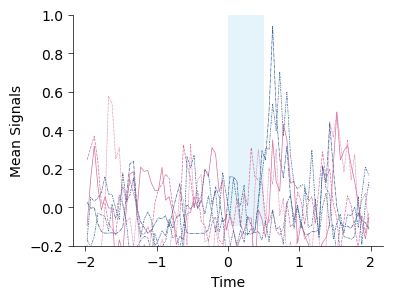

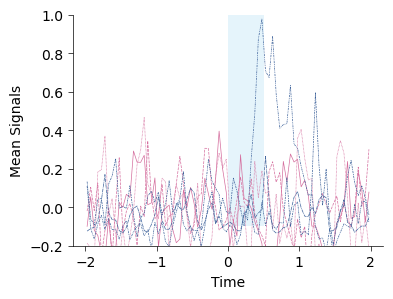

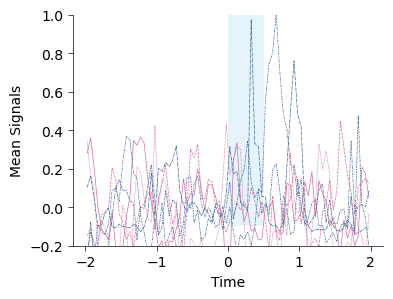

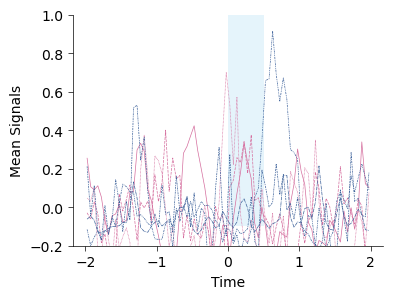

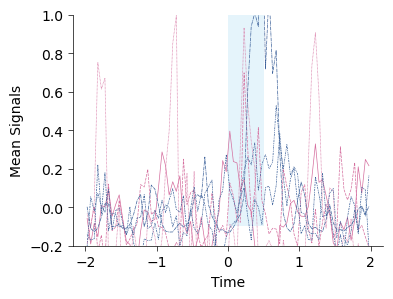

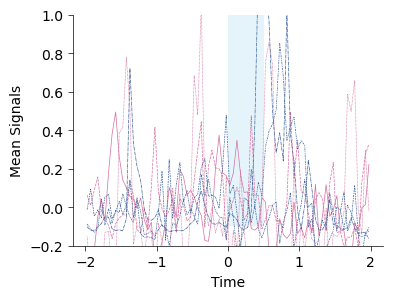

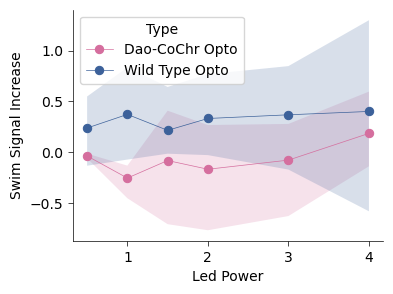

In [8]:
if exists(join(figdata, f" {code_id} [Opt Pretest GP].pkl")) == False:
    OptPreTestGPData = {
        "FishID": [],
        "Time": [],
        "Mean Signals": [],
        "Led Power": [],
        "Led Bin": [],
        "Type" : []
    }
    for i in range(100, len(f_dao_opt)):
        if f_dao_opt['session'][i] == 2:
            print(f"Fish: {f_dao_opt['ID'][i]}")
            data = segmentation_gp(f_dao_opt['filename'][i])
            data['mean_signals'] = (data['realigned_fltCh0'] + data['realigned_fltCh1']) / 2
            time_bins = np.unique(data['realigned_time'])
            led_bins = np.unique(data['led_bin'])
            for led_b in range(6):
                mean_signals_opt = np.zeros(len(time_bins))
                mean_signals_shuf = np.zeros(len(time_bins))
                led_power_opt = np.zeros(len(time_bins))
                led_power_shuf = np.zeros(len(time_bins))
                led_power_bin_opt = np.zeros(len(time_bins))
                led_power_bin_shuf = np.zeros(len(time_bins))
            
                for j, t in enumerate(time_bins):
                    mean_signals_opt[j] = np.mean(data['mean_signals'][(data['realigned_time'] == t) & (data['Type'] == 'Opto') & (data['led_bin'] == led_b)])
                    mean_signals_shuf[j] = np.mean(data['mean_signals'][(data['realigned_time'] == t) & (data['Type'] == 'Shuf') & (data['led_bin'] == led_b)])
                    led_power_opt[j] = data['led_power'][(data['realigned_time'] == t) & (data['Type'] == 'Opto') & (data['led_bin'] == led_b)][0]
                    led_power_shuf[j] = 0.5
                    led_power_bin_opt[j] = data['led_bin'][(data['realigned_time'] == t) & (data['Type'] == 'Opto') & (data['led_bin'] == led_b)][0]
                    led_power_bin_shuf[j] = 0
                
                OptPreTestGPData['FishID'].append(np.repeat(f_dao_opt['ID'][i], len(time_bins)*2))
                OptPreTestGPData['Time'].append(np.concatenate([time_bins, time_bins]))
                OptPreTestGPData['Mean Signals'].append(np.concatenate([mean_signals_opt, mean_signals_shuf]))
                OptPreTestGPData['Led Power'].append(np.concatenate([led_power_opt, led_power_shuf]))
                OptPreTestGPData['Led Bin'].append(np.concatenate([led_power_bin_opt, led_power_bin_shuf]))
                type_name = f"{f_dao_opt['Genotype'][i]} Opto"
                type_name_shuf = f"{f_dao_opt['Genotype'][i]} Shuf"
                OptPreTestGPData['Type'].append(np.concatenate([np.repeat(type_name, len(time_bins)), np.repeat(type_name_shuf, len(time_bins))]))
    
    for k in OptPreTestGPData.keys():
        OptPreTestGPData[k] = np.concatenate(OptPreTestGPData[k])
        
    OptPreTestGPData = LengthAlignedDict(OptPreTestGPData)
    with open(join(figdata, f"{code_id} [Opt Pretest GP].pkl"), 'wb') as f:
        pickle.dump(OptPreTestGPData, f)
        
    OptPreTestD = pd.DataFrame(OptPreTestGPData)
    OptPreTestD.to_excel(join(figdata, f"{code_id} [Opt Pretest GP].xlsx"), index=False)
    print(len(OptPreTestGPData))
else:
    with open(join(figdata, f"{code_id} [Opt Pretest GP].pkl"), 'rb') as f:
        OptPreTestGPData: LengthAlignedDict = pickle.load(f)

for ledb in range(6):
    subdata = OptPreTestGPData.subdict(
        np.where((OptPreTestGPData['Led Bin'] == ledb) &
                 (OptPreTestGPData['Type'] != 'Dao-CoChr Shuf') &
                 (OptPreTestGPData['Type'] != 'Wild Type Shuf'))[0]
    )
    fig  = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    sns.lineplot(
        x='Time',
        y='Mean Signals',
        hue='Type',
        data=subdata,
        style='FishID',
        palette=[ChannelColors[0], ChannelColors[1]],
        linewidth=0.5,
        err_kws={'edgecolor': None},
        ax=ax,
        legend=False
    )
    ax.fill_betweenx([-0.1, 1], 0, 0.5, color='#a9dcf5', alpha=0.3, edgecolor=None)
    ax.set_ylim(-0.2, 1)
    plt.show()

idx_bef = np.where(
    ((OptPreTestGPData['Time'] > -0.05) & (OptPreTestGPData['Time'] < 0) &
                 (OptPreTestGPData['Type'] != 'Dao-CoChr Shuf') &
                 (OptPreTestGPData['Type'] != 'Wild Type Shuf'))
)[0]
idx_aft = np.where(
    ((OptPreTestGPData['Time'] > 0.5) & (OptPreTestGPData['Time'] < 0.55) &
                 (OptPreTestGPData['Type'] != 'Dao-CoChr Shuf') &
                 (OptPreTestGPData['Type'] != 'Wild Type Shuf'))
)[0]
res = {
    "FishID": OptPreTestGPData['FishID'][idx_bef],
    "Swim Signal Increase": OptPreTestGPData['Mean Signals'][idx_aft] - OptPreTestGPData['Mean Signals'][idx_bef],
    "Led Power": OptPreTestGPData['Led Power'][idx_bef],
    "Type": OptPreTestGPData['Type'][idx_bef]
}

fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='Led Power',
    y='Swim Signal Increase',
    hue='Type',
    data=res,
    palette=[ChannelColors[0], ChannelColors[1]],
    linewidth=0.5,
    err_kws={'edgecolor': None},
    marker='o',
    markeredgecolor=None,
    ax=ax
)
plt.show()


# Sequentially Linear Track